<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5221: Intelligent Image and Video Analysis</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 4.1: Image Segmentation</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Image Segmentation**

In object recognition, there are four types of segmentation:

| Type | Description |
|---|---|
| Semantic Segmentation | Assigns a class label to every pixel in the image |
| Classification & Localisation | Predicts the location and class of a single object |
| Object Detection | Detects multiple objects along with their classes and locations |
| Instance Segmentation | Combines pixel-level labelling with detection of multiple object classes and locations |

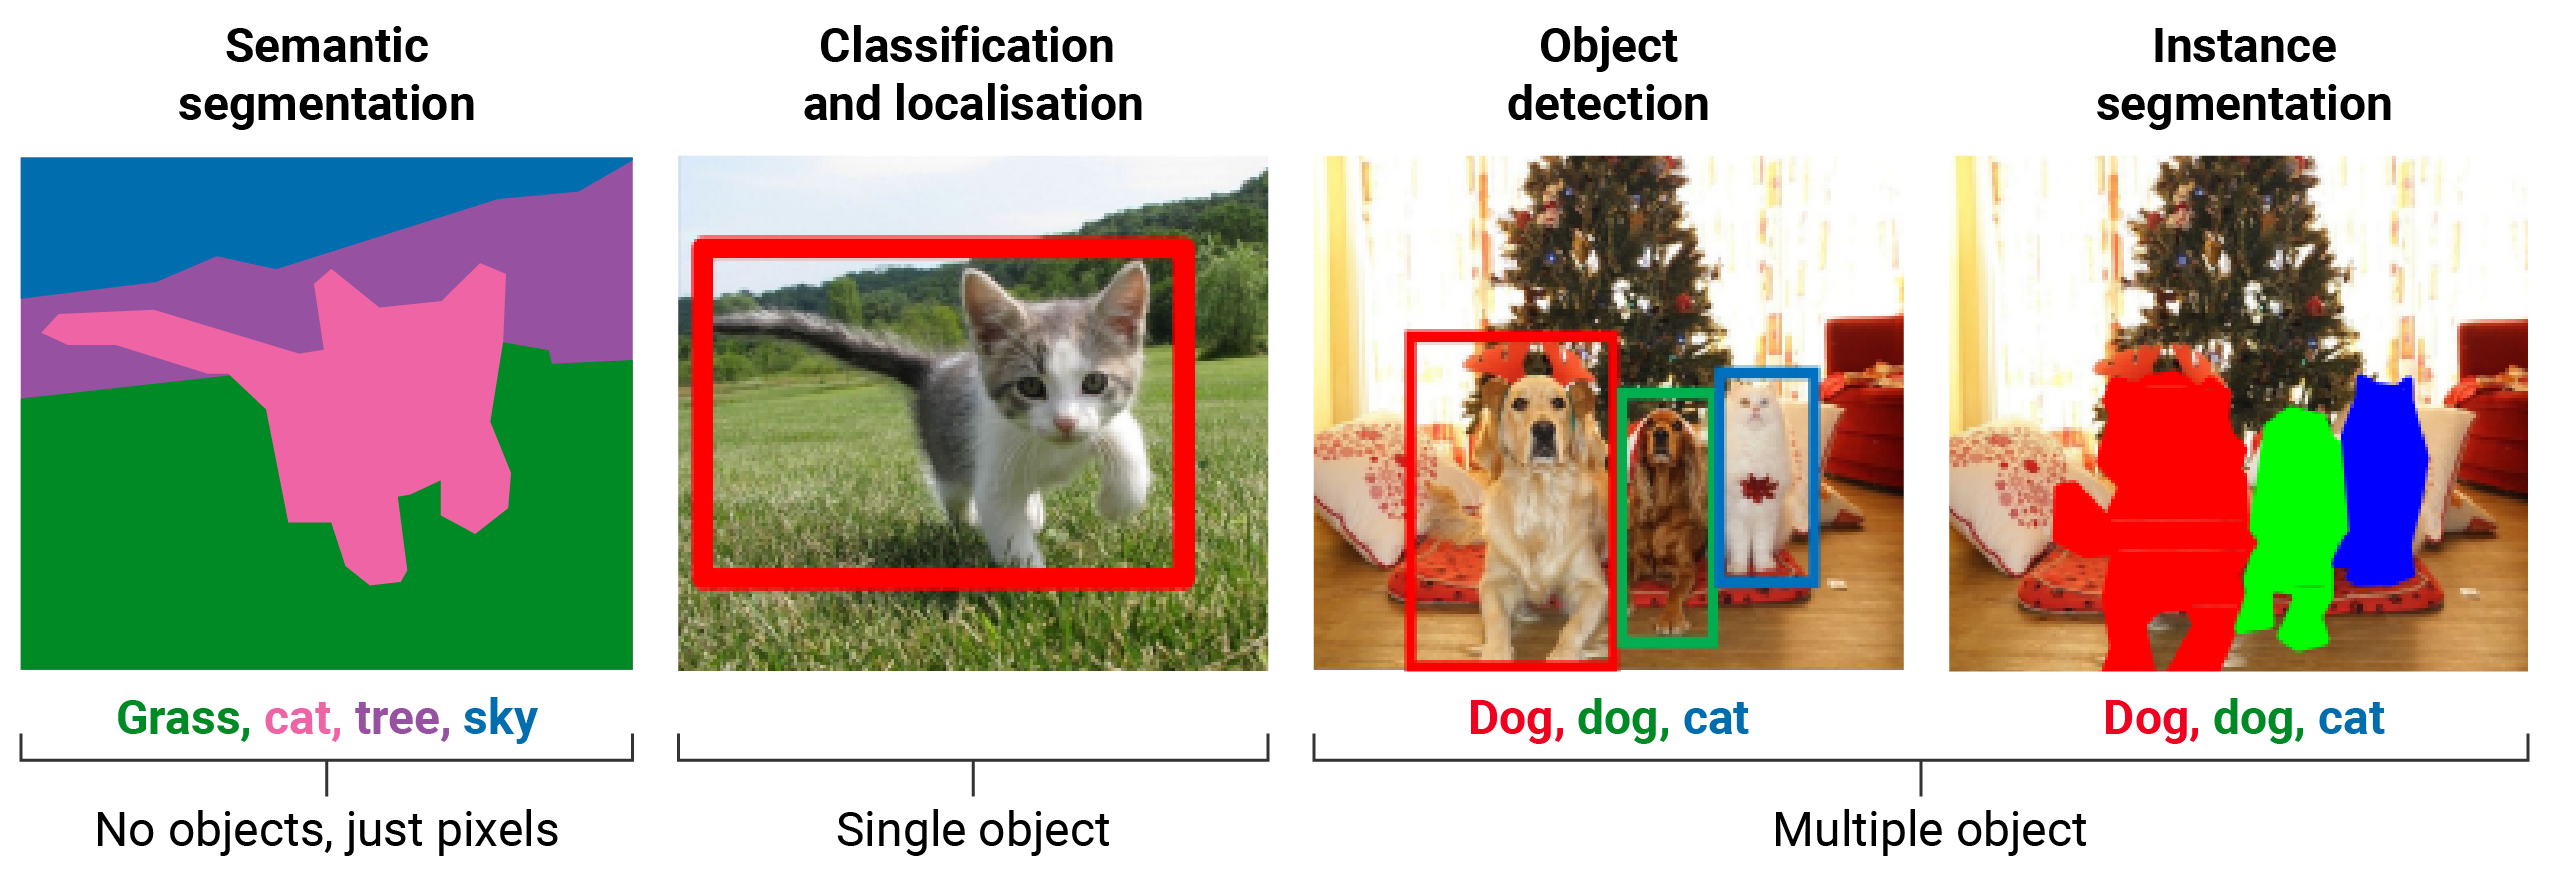

*Source: Four types of segmentation (2022) courtesy of the Faculty of Information Technology*

In this module, we focus on the first task — **semantic segmentation**.

Given an input image, segmentation classifies each pixel into a category. The goal is to partition the image into coherent "objects", which involves two core processes:

- **Bottom-up:** group pixels that share similar visual features
- **Top-down:** group pixels that likely belong to the same object

Both approaches aim to:
1. **Gather features** that belong together
2. **Produce a compact intermediate representation** that describes the key parts of the image (or video)

#### **Top-Down vs. Bottom-Up**

| Approach | Grouping Rationale |
|---|---|
| Top-down | Pixels belong together because they come from the same object |
| Bottom-up | Pixels belong together because they look similar |

<br>

### **Simple Segmentation Example**

Consider an image containing two objects on a white background — a black circle and a grey square that slightly overlap. Each region has a distinct intensity, giving us three groups:

A histogram of pixel intensities would show three distinct peaks, one for each group. We could label every pixel according to which of these primary intensities it belongs to.

But what happens when the image is more complex, for example, if we add noise? The intensity plot becomes messier and it is no longer obvious where the three main groups are. This is where **clustering** comes in.

<br>

### **The Goal of Clustering**

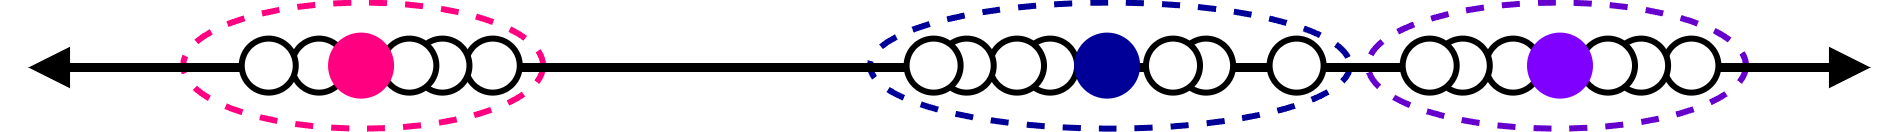

The idea is to choose $k$ representative centres and assign every pixel to its nearest centre. The best cluster centres are those that **minimize the total distance** between all points and their assigned centre.

$$\sum_{\text{clusters } i} \sum_{\text{points } p \text{ in cluster } i} \|p - c_i\|^2$$

Where:
- $c_i$ = the centre of cluster $i$
- $p$ = a data point (e.g., a pixel intensity) assigned to cluster $i$
- $\|p - c_i\|^2$ = the squared distance between point $p$ and its cluster centre

In other words, we want each point as close as possible to the centre it is assigned to. A basic algorithm for solving this is **K-Means**, which will be discussed next.

---

### **Clustering by K-Means**

K-Means is a widely used clustering algorithm. The core idea is to randomly initialise $k$ cluster centres, then iteratively refine them using the steps below.

#### **The Algorithm**

#### **Algorithm Steps**
1. **Initialize:** Select K value and randomly place K cluster centroids in the equipment parameter space
2. **Assignment:** Assign each equipment unit to the nearest centroid based on operational similarity
3. **Update:** Recalculate each centroid as the mean of all equipment units in that cluster
4. **Convergence Check:** If no equipment units change clusters, algorithm terminates
5. **Iterate:** Otherwise, return to step 2

#### **Industrial Implementation Example**
**Scenario:** Classifying 50 industrial motors using power consumption and vibration levels

**Step 1 - Initialization (K=3):**
- Randomly place 3 centroids in power-vibration parameter space
- Each centroid represents a potential object classification

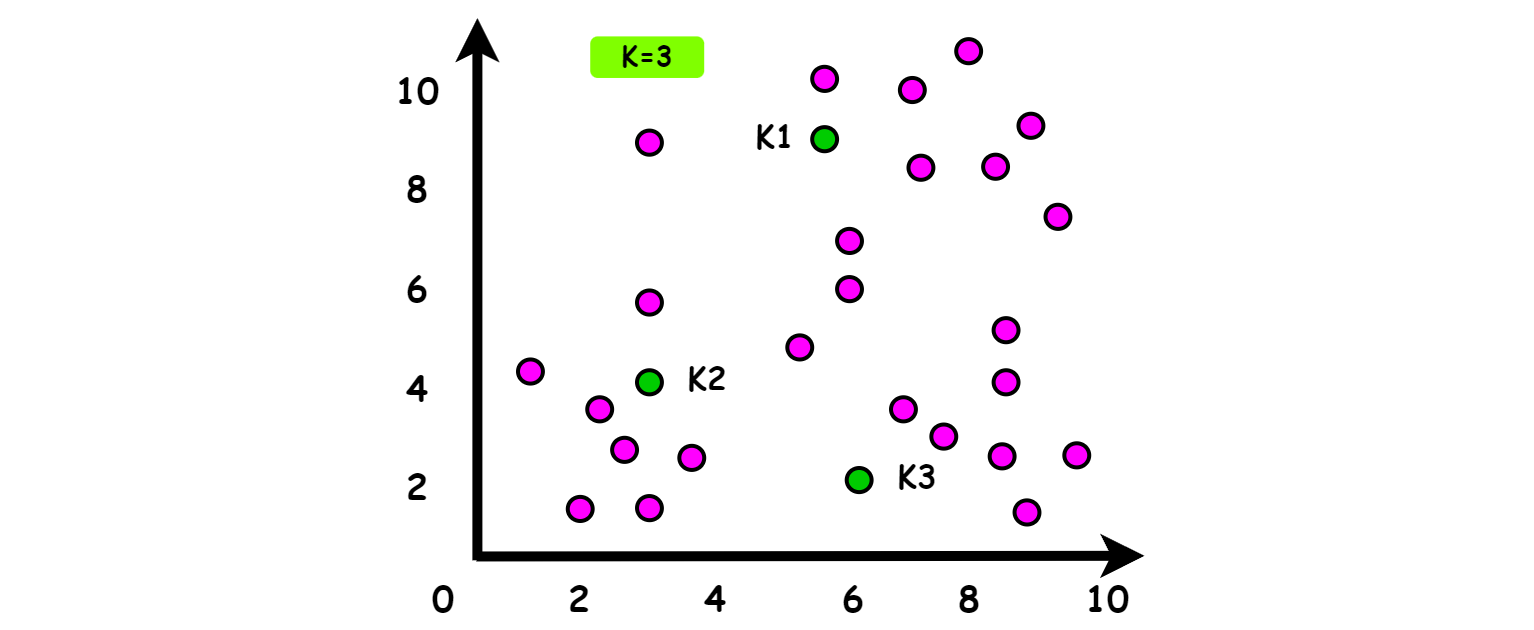

<br>

**Step 2 - Equipment Assignment:**
- Calculate distance from each object to all 3 centroids
- Assign each object to closest centroid cluster

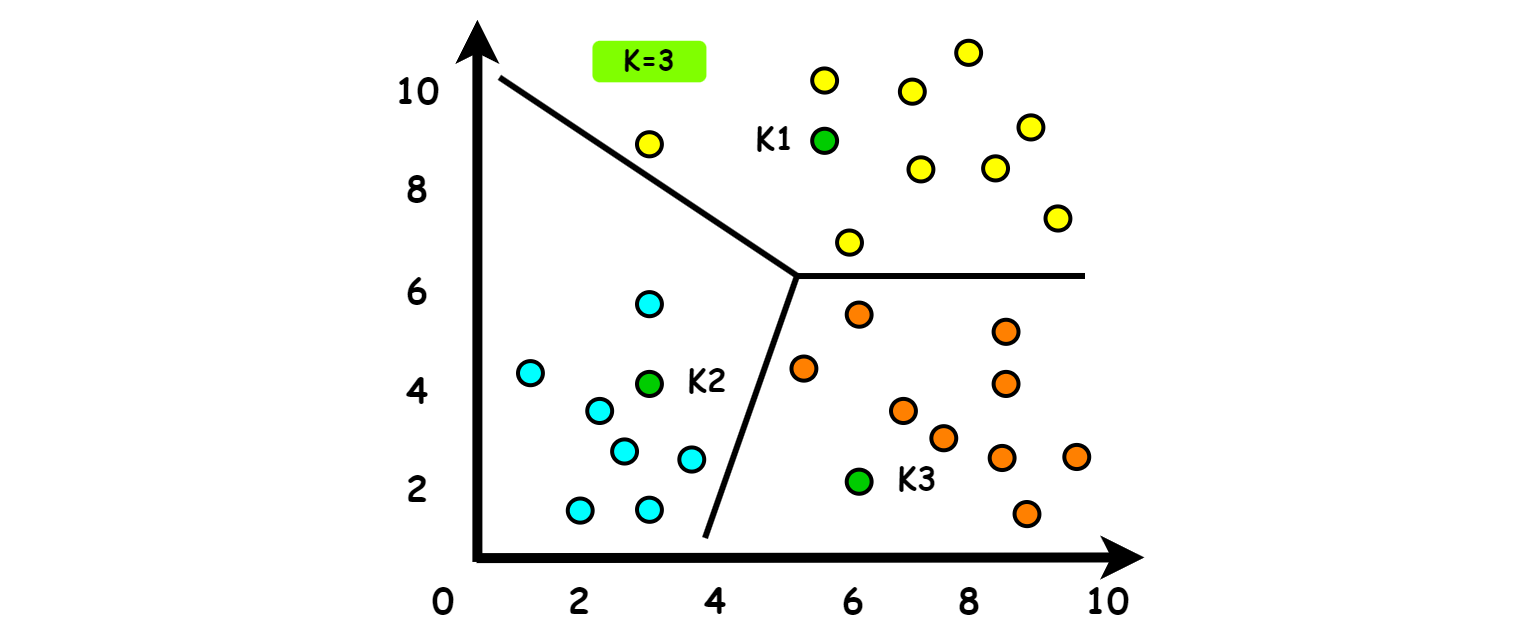

<br>

**Step 3 - Centroid Recalculation:**
- For each cluster, compute average x and y values
- Move centroid to this average position

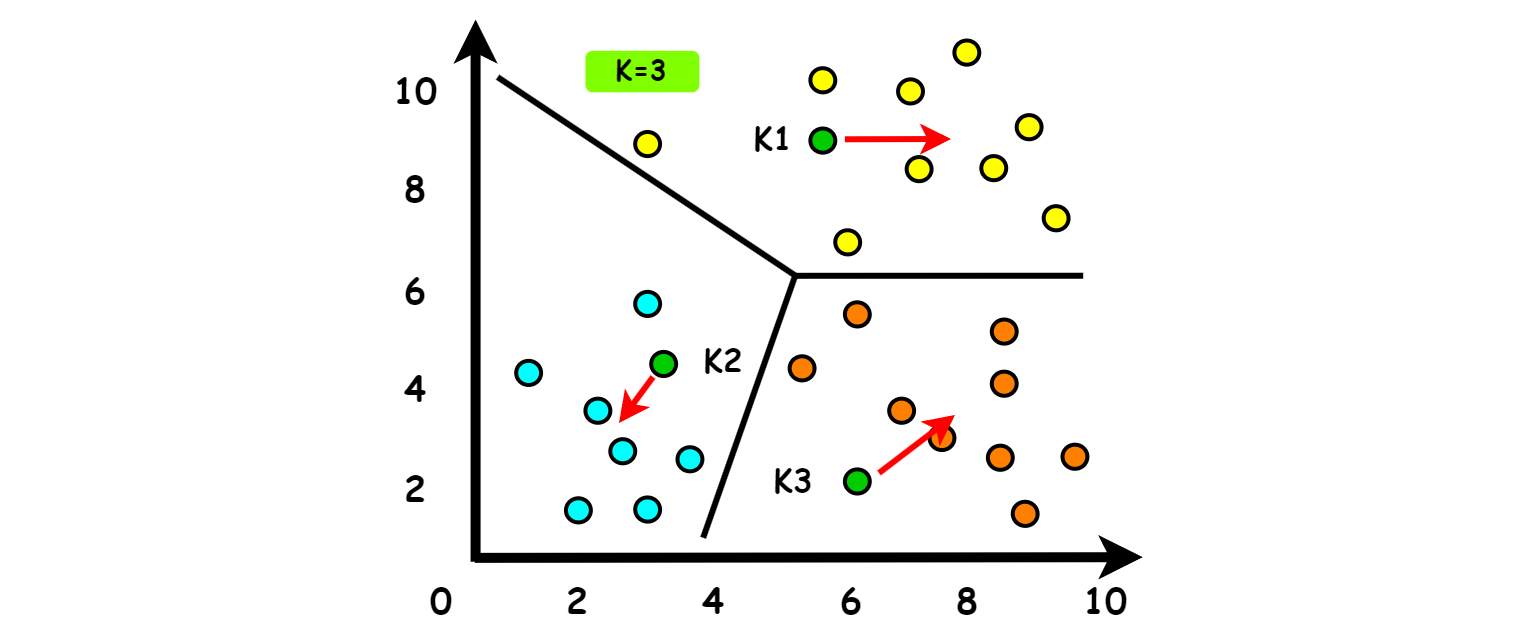

<br>

**Step 4 - Iteration:**
- Repeat assignment and update until object classifications stabilize

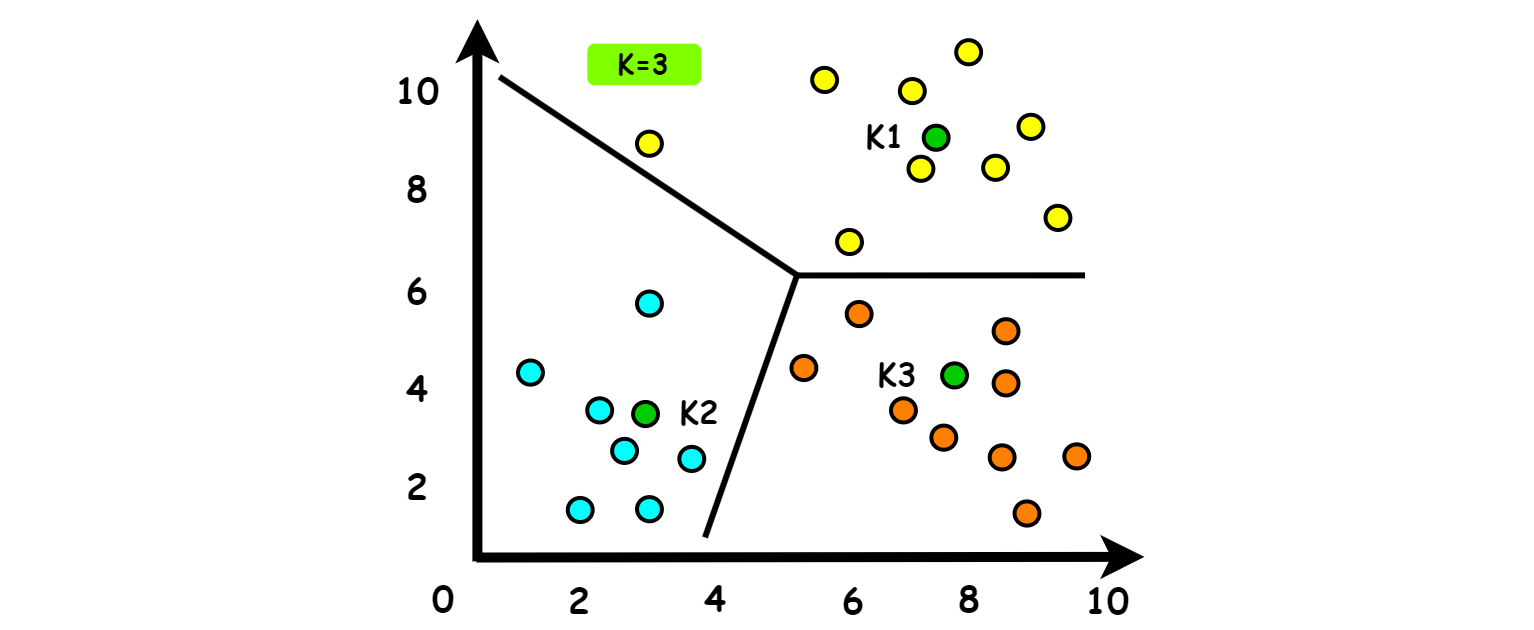

<br>

#### **Properties**

- The algorithm is **guaranteed to converge** to some solution
- However, it may converge to a **local minimum** — not necessarily the global minimum of the objective function

<br>

#### **Pros and Cons of K-Means**

| Pros | Cons |
|---|---|
| Simple and fast to compute | $k$ is a hyperparameter that must be set manually |
| Converges to a local minimum of within-cluster squared error | Sensitive to the choice of initial centres |
| | Sensitive to outliers |
| | Can only detect spherical (globular) clusters |
| | Assumes that a mean can be meaningfully computed |

<br>

#### **Limitations — Two Examples**

**Example 1 — Outlier Sensitivity:**
Consider a scatterplot with two natural groups and one outlier far from both. In the ideal clustering, the outlier is excluded from the nearby cluster. However, K-Means may pull a cluster centre toward the outlier, causing nearby points to be wrongly assigned. Points that are close together end up in different clusters because the outlier distorts the centre.

**Example 2 — Non-Linear Boundaries:**
Consider two clusters that are naturally separated by a curved boundary rather than a straight line. Since K-Means divides space using linear boundaries (each point goes to its nearest centre), it cannot correctly separate clusters that require a non-linear decision boundary.

---